# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage",usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean()*100)

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id        0.000
first_name     0.000
last_name      0.000
age            0.000
city          11.725
reg_date       0.000
plan           0.000
churn_date    88.350
dtype: float64


In [11]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
   *En la tabla de users: la columna de "city" y "churn_date" tienen valores faltantes en un 11% y 88% respectivamente. En el caso de city investigaria para imputar y en la columna de churn_date lo ignoraria ya que tiene un porcentaje alto alto de nulos.*
  La tabla de usage: las columnas de "date", "duration" y "length" tienes valores faltantes en un 0.12%, 55% y 44% respectivamente. En los casos de nulos en esta tabla investigaria los faltantes en las tres columnas.
- Indica qué harías: ¿imputar, eliminar, ignorar?

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id`: va en orden y no tiene faltantes
- La columna `age`: no tiene faltantes y tambien se podria tomar como categorica por el rango de edades

In [13]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`: no van en orden el user_id con respecto al id.
- Las columnas 'duration' y 'length': tienen valores faltantes.

In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
print(users[columnas_user])
for columna in columnas_user:
    print(users[columna].value_counts())
    print()

          city     plan
0     Medellín   Basico
1            ?   Basico
2         CDMX   Basico
3       Bogotá  Premium
4          GDL   Basico
...        ...      ...
3995  Medellín   Basico
3996  Medellín  Premium
3997    Bogotá  Premium
3998    Bogotá   Basico
3999    Bogotá   Basico

[4000 rows x 2 columns]
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

Basico     2595
Premium    1405
Name: plan, dtype: int64



- La columna `city`:cuenta con sentinels
- La columna `plan`: son los planes y no se nota nada extraño

In [15]:
# explorar columna categórica de usage
print(usage['type'].value_counts())

text    22092
call    17908
Name: type, dtype: int64


- La columna `type`: no muestra sentinels


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
  La table usage sus columnas de "duration" y "length" cuentan con valores faltantes
  La table users en su columna "city" se encontraron sentinels
- ¿Qué acción tomarías?  investigar

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users["reg_date"], errors ='coerce')
users.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     4000 non-null   int64         
 1   first_name  4000 non-null   object        
 2   last_name   4000 non-null   object        
 3   age         4000 non-null   int64         
 4   city        3531 non-null   object        
 5   reg_date    4000 non-null   datetime64[ns]
 6   plan        4000 non-null   object        
 7   churn_date  466 non-null    object        
dtypes: datetime64[ns](1), int64(2), object(5)
memory usage: 250.1+ KB


In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors ="coerce")
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   id        40000 non-null  int64         
 1   user_id   40000 non-null  int64         
 2   type      40000 non-null  object        
 3   date      39950 non-null  datetime64[ns]
 4   duration  17924 non-null  float64       
 5   length    22104 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(1)
memory usage: 1.8+ MB


In [18]:
# Revisar los años presentes en `reg_date` de users
años_users = users["reg_date"].dt.year.unique()
print(años_users)

[2022 2026 2023 2024]


En `reg_date`, ... haz doble clic en este bloque y escribe qué ves.
Se aprecian años invalidos como el del 2026

In [19]:
# Revisar los años presentes en `date` de usage
años_usage = usage["date"].dt.year.unique()
print(años_usage)

[2024.   nan]


En `date`, ... haz doble clic en este bloque y escribe qué ves.  Se aprecian faltantes
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
  Si aparecen años imposibles y tenemos faltantes
- ¿Qué harías con ellas? imputar

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999,age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts(dropna = False)

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [22]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year == 2026, 'reg_date'] = pd.NaT
# Verificar cambios
users['reg_date'].describe()

count                              3960
unique                             3960
top       2024-06-27 06:08:22.325581392
freq                                  1
first               2022-01-01 00:00:00
last                2024-12-31 00:00:00
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:
# Verificación MAR en usage (Missing At Random) para duration
usage["duration"].isna().groupby(usage["type"]).mean().sort_values(ascending=False)

type
text    0.999276
call    0.000000
Name: duration, dtype: float64

In [24]:
# Verificación MAR en usage (Missing At Random) para length
usage["length"].isna().groupby(usage["type"]).mean().sort_values(ascending=False)


type
call    0.99933
text    0.00000
Name: length, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length En la columna de suracion los datsos se consentran en llamadas, ya que los textos no tienen duracion por eso aparecen como nulos. Caso contrario a la longitud que se consentra en la categoria de texto porque esta no tiene duracion sino longitud.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [44]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas
usage["duration"] = (usage["duration"])

# Agrupar información por usuario
usage_agg =usage.groupby('user_id').agg({
    "is_text": 'sum',
    "is_call": 'sum',
    "duration": 'sum'
        }).reset_index()

# observar resultado
usage_agg.head()

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74
3,10003,11,3,8.99
4,10004,4,3,8.01


In [26]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration': 'cant_minutos_llamada'
})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
# Combinar la tabla agregada con el dataset de usuarios
clean_users = pd.merge(users, usage_agg, on = ['user_id'], how = 'left')
clean_users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01
...,...,...,...,...,...,...,...,...,...,...,...
3995,13995,Ana,Lopez,60.0,Medellín,2024-12-29 21:42:48.342085520,Basico,NaN,6.0,3.0,21.24
3996,13996,Carlos,Ramirez,24.0,Medellín,2024-12-30 04:17:06.256564144,Premium,NaN,4.0,3.0,2.81
3997,13997,Ana,Lopez,58.0,Bogotá,2024-12-30 10:51:24.171042768,Premium,NaN,5.0,3.0,11.34
3998,13998,Mariana,Lopez,57.0,Bogotá,2024-12-30 17:25:42.085521392,Basico,NaN,6.0,6.0,22.95


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [28]:
# Resumen estadístico de las columnas numéricas
clean_users[['age','cant_mensajes','cant_llamadas','cant_minutos_llamada']].describe()


,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.122250,5.524381,4.478120,23.317054
std,17.690408,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [29]:
# Distribución porcentual del tipo de plan
clean_users['plan'].value_counts(normalize=True)

Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

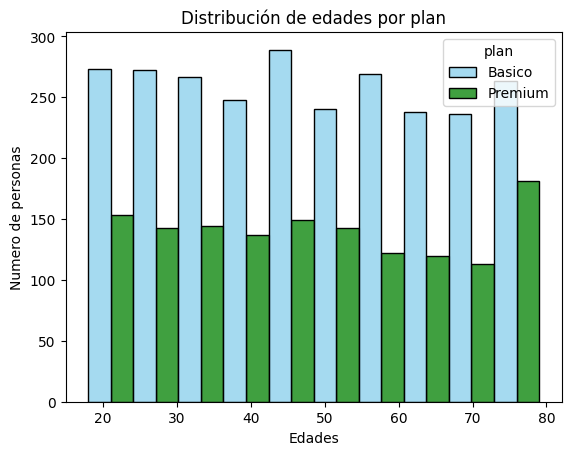

In [30]:
# Histograma para visualizar la edad (age)


sns.histplot(data= clean_users, x="age", hue="plan", bins=10, palette=['skyblue','green'], kde=False, multiple="dodge")
plt.xlabel('Edades')
plt.ylabel('Numero de personas')
plt.title('Distribución de edades por plan')
plt.show()



💡Insights: 
-Dentro del plan Premium ahi mayor proporcion de personas con edades cercanas a las 80 años.
- Distribución del plan basico sobresale del plan premium pero es estandar en las diferentes edades.
- La distrubucion del plan premim pareceria sesgada a la derecha asta las edades cercanas a las de 80 años.

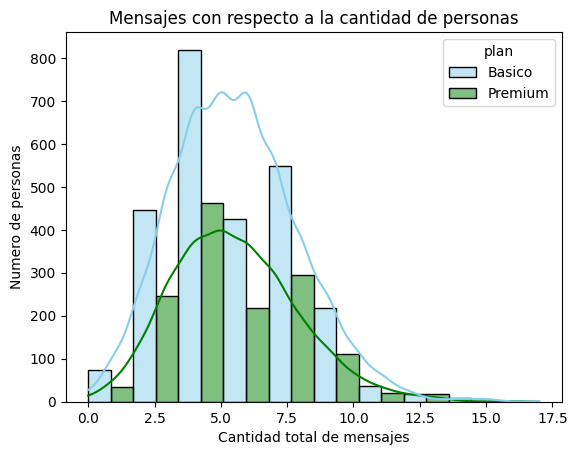

In [31]:
# Histograma para visualizar la cant_mensajes

sns.histplot(data= clean_users, x="cant_mensajes", hue="plan", bins=10, palette=['skyblue','green'], kde=True, multiple='dodge')
plt.xlabel('Cantidad total de mensajes')
plt.ylabel('Numero de personas')
plt.title('Mensajes con respecto a la cantidad de personas')

plt.show()




💡Insights: 
- Se observa un ligero sesgo asia la derecha en ambos planes
- La cantidad de mensaje que mas se envian estan entre los 2.5 y 5.

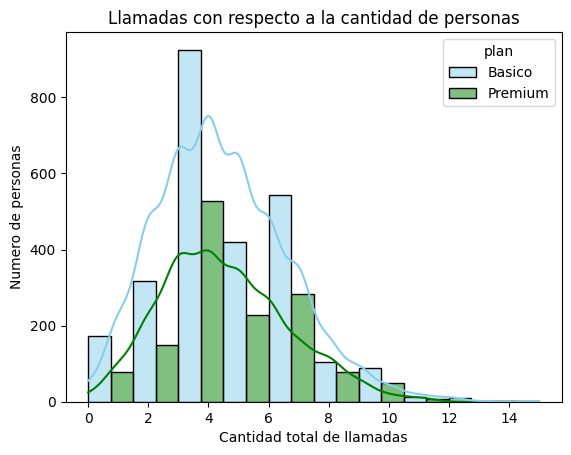

In [32]:
# Histograma para visualizar la cant_llamadas

sns.histplot(data= clean_users, x="cant_llamadas", hue="plan", bins=10, palette=['skyblue','green'], kde=True, multiple='dodge')
plt.xlabel('Cantidad total de llamadas')
plt.ylabel('Numero de personas')
plt.title('Llamadas con respecto a la cantidad de personas')
plt.show() 


💡Insights: 
- Distribución ...
  Mayormente el numero de llamadas se consentran entre en el 3 y 6 llamadas en el plan basico, despues de la llamada numero 6 se observa sesgo asia la derecha lo cual quiere decir que el numero de llamadas va disminuyendo a partir de ahi.
  el Mayor numero de llamadas en el plan Premium se consentra en la llamada numero 4 y llamada numero 7, se ahi se observa sesgo asia la derecha lo cual indica disminucion en el numero de llamadas mas altas.

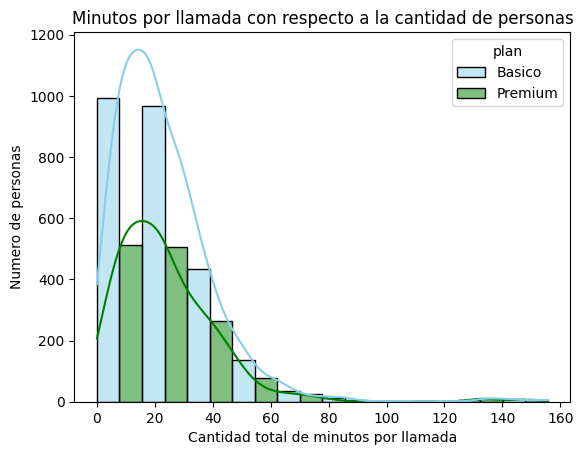

In [33]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data= clean_users, x="cant_minutos_llamada", hue="plan", bins=10, palette=['skyblue','green'], kde=True, multiple='dodge')
plt.xlabel('Cantidad total de minutos por llamada')
plt.ylabel('Numero de personas')
plt.title('Minutos por llamada con respecto a la cantidad de personas')
plt.show() 

💡Insights: 
 Se observa sesgo asia la derecha en ambos planes donde la mayor durabilidad es de 0 a 30 min por llamada

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

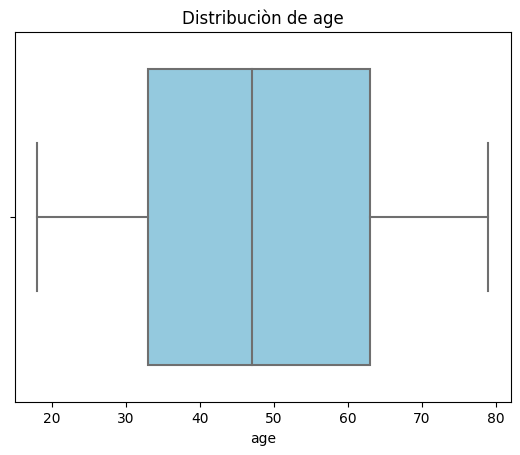

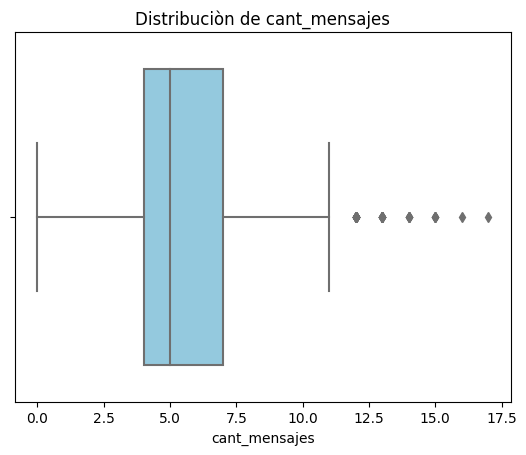

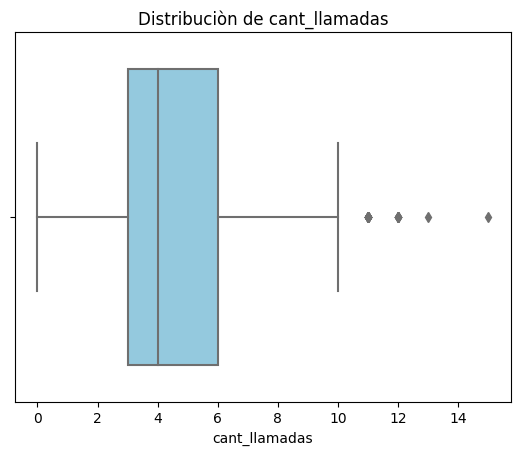

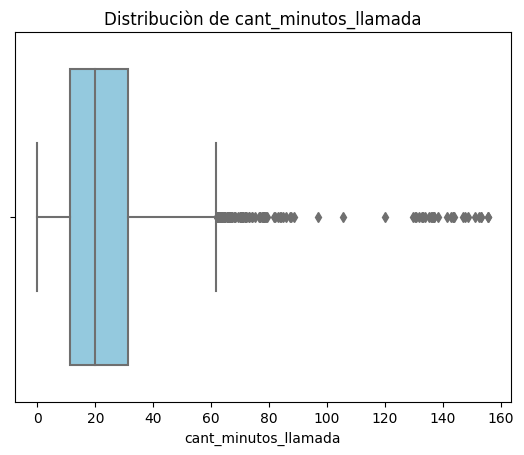

In [34]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas: 
    sns.boxplot(x=clean_users[col], color="skyblue")
    plt.title(f"Distribuciòn de {col}")
    plt.xlabel(col)
    plt.show()



💡Insights: 
- Age: ...No presenta outliers
- cant_mensajes: ...Si presenta outliers
- cant_llamadas: ...Si presenta outliers
- cant_minutos_llamada: ...Si presenta outliers

In [35]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes','cant_llamadas','cant_minutos_llamada']
for col in columnas_limites:
    q1 = clean_users[col].quantile(0.25)
    q3 = clean_users[col].quantile(0.75)
    IQR = q3 -q1 
    limite_inferior = q1 - 1.5 * IQR
    limite_superior = q3 + 1.5 * IQR
    print(f'columna:{col}') 
    print(f'limite inferior:{limite_inferior}')
    print(f'limite superior:{limite_superior}')
    print()


columna:cant_mensajes
limite inferior:-0.5
limite superior:11.5

columna:cant_llamadas
limite inferior:-1.5
limite superior:10.5

columna:cant_minutos_llamada
limite inferior:-19.322500000000005
limite superior:61.8575



In [36]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile = clean_users[['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].copy()
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?En el limite superior podemos ver que el resultado es de 11.5 y su maximo es de 17, la diferencia de 5.5 es pequeña no dara direncia en los resultados por lo tanto es mejor mantenerla.
- cant_llamadas: mantener o no outliers, porqué? Su limite superior es de 10.5 y su maximo es de 15, es mejor matenerla por su pequeña direncia de 4.5
- cant_minutos_llamada: mantener o no outliers, porqué? En este caso la direncia de su limite superior (61.84) y su maxima (155.6) es del mas del doble, pero puede ser posible tener llamadas tan duraderas.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [53]:
# Crear columna grupo_uso
user_profile['grupo_uso'] = np.where((user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5), 'Bajo uso',
                                    np.where((user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10), 'Uso medio', 'Alto uso'))
user_profile['grupo_uso'].value_counts()

Uso medio    2943
Bajo uso      778
Alto uso      279
Name: grupo_uso, dtype: int64

In [38]:
# verificar cambios
user_profile.head()

,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,7.0,3.0,23.70,Uso medio
1,5.0,10.0,33.18,Alto uso
2,5.0,2.0,10.74,Uso medio
3,11.0,3.0,8.99,Alto uso
4,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [52]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = np.where(clean_users['age'] < 30, 'Joven',
                                     np.where(clean_users['age'] < 60, 'Adulto', 'Adulto Mayor'))
user_profile['grupo_edad'].value_counts()

Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64

In [40]:
# verificar cambios
user_profile.head()

,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,7.0,3.0,23.70,Uso medio,Adulto
1,5.0,10.0,33.18,Alto uso,Adulto
2,5.0,2.0,10.74,Uso medio,Adulto
3,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

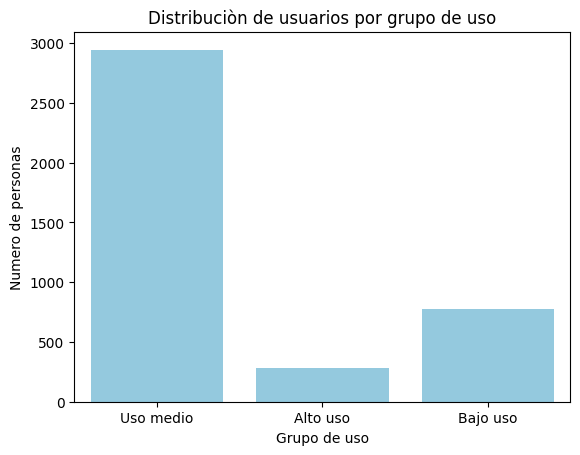

In [48]:
# Visualización de los segmentos por uso

sns.countplot(data = user_profile, x='grupo_uso', color='skyblue')
plt.xlabel('Grupo de uso')
plt.ylabel('Numero de personas')
plt.title('Distribuciòn de usuarios por grupo de uso')
plt.show()


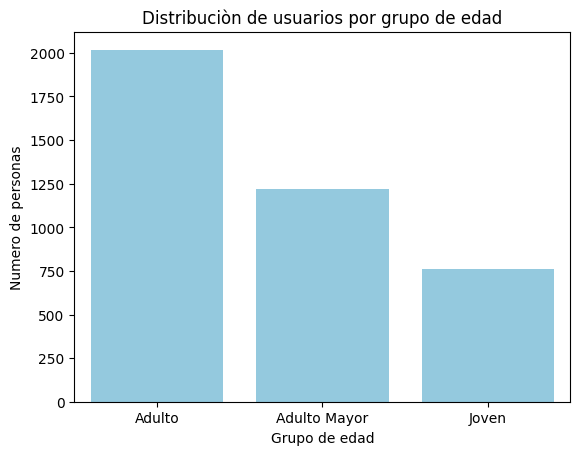

In [49]:
# Visualización de los segmentos por edad
sns.countplot(data = user_profile, x='grupo_edad', color='skyblue')
plt.xlabel('Grupo de edad')
plt.ylabel('Numero de personas')
plt.title('Distribuciòn de usuarios por grupo de edad')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
 Los datos originales contaban con faltantes, columnas inecesarias, valores atipicos, estaban mal algunos tipos de datos como el de 'fecha'.
 En la tabla plans no hubo faltantes, en la tabla users la columna con mas faltantes fue la de churn_date con solo 466 datos de 4000 filas, teniendo asi solo el 11.65% de los datos, aunque esta columna no fue relevente para el analisis en esta ocacion. Y en la tabla usage, la columna con mas faltantes fue 'duration' con 17924 datos de 40000, contando con el 44.81% de los datos.

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?
Se pudo observar que el uso mas alto es el de "uso medio" que son las personas que tienes la cantidad de llamadas y mensajes entre 5 a 10 y las personas que mas usan el servicio son las de mayor a 60 años
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué? las personas con edades de 30 años en adelante ya que representan el 81% de los clientes.
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio? Cantidad de minutos por llamadas, unas llegaban a los 155 minutos. Son muy pocas no afectaria.
- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?
Como el mayor uso se consentra entre las personas que hacen de 5 a 10 llamadas y mensajes y la mayor poblecion es de 30 años en adelante mis recomendaciones serian:
1)Hacer un plan intermedio para ese rango de necesidades de 5 a 10 llamadas y mensajes.
2)Dar plan premium gratis por cierto tiempo para que las personas prueben el servicio y se animen a quedarse con el plan premium.
3)Dar marketing a las llamadas fomentando el asercamiento a personas por este medio. 

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- faltantes en algunas columnas
- valores atipicos
- estaban mal algunos tipos de datos
- columnas innecesarias
🔍 **Segmentos por Edad**
- La mayor parte de los clientes son de edades de 30 a 60 años los cuales estan en la categia de adultos y representan el 50%
- La menor parte esta en el segmento Joven los cuales son los menores de 30 años y representan el 19%
- Los adultos mayores representan el 31%


📊 **Segmentos por Nivel de Uso**
- La mayor parte se encuentra en el medio uso que son las personas que hacen entre 5 y 10 llamadas y mensajes, representando un 73.5%
- La menor parte esta en el Alto que son los clientes que realizan mas de 10 llamadas y mensajes, representado por un 6.9%
- Y el bajo uso esta representado por un 19.6% que son los clientes que realizan menos de 5 llamadas y mensajes


➡️ Esto sugiere que ...


💡 **Recomendaciones**
- Se consentren en las personas de 30 años en adelante
- Hacer un plan intermedio para los clientes de Medio uso

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`